# Matryoshka dim-truncation — `study-A-fit`

**Branch**: `research/chunking-eval` · **Companion to**: `notebooks/A-fit-eval.ipynb`

## Question

Can we safely drop the embeddings to their first $N$ dimensions for downstream retrieval? Smaller vectors mean cheaper Chroma/Qdrant footprint and faster cosine math; the open question is where retrieval quality starts degrading.

## Method

`Alibaba-NLP/gte-multilingual-base` is **768-d**, trained with Matryoshka heads at `{64, 128, 256, 512, 768}`, so a prefix of the output is itself a meaningful embedding once re-L2-normalised. We loop over those prefixes, score every `(query, scenario)` pair using the existing `eval.score_queries` pipeline, and plot Recall@5 vs prefix dim per scenario.

No re-encode — the truncation runs entirely in memory off the existing per-scenario embedding shards loaded by `eval.load_eval_inputs`.

## Scope of this notebook

Scaffold only — load → sanity → sweep → headline plot. Per-`token_bucket` / per-`position_bucket` stratification, paired-bootstrap Δ tables, and the verdict cell are TODO follow-ups (see section 6).

## 1 — Setup

In [2]:
import os
import sys
from pathlib import Path

# When running from the notebook (cwd = notebooks/), reach the src/ layout.
REPO_ROOT = Path(os.environ.get("IMPRESSO_REPO_ROOT", Path.cwd().resolve())).resolve()
if (REPO_ROOT / "notebooks").is_dir() is False and (REPO_ROOT.parent / "notebooks").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

STUDY_CONFIG_PATH = REPO_ROOT / "configs/research/study-A-fit.yaml"
assert STUDY_CONFIG_PATH.exists(), f"missing: {STUDY_CONFIG_PATH}"
print(f"study config: {STUDY_CONFIG_PATH}")

study config: /Users/adrien/Documents/nlp2/impresso-text-embedder/configs/research/study-A-fit.yaml


In [3]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from impresso_text_embedder.research import eval as ev
from impresso_text_embedder.research.scenario_builder import ScenarioRegistry
from impresso_text_embedder.research.study_config import load_study_config

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logging.getLogger("impresso_text_embedder").setLevel(logging.INFO)
logging.getLogger("botocore").setLevel(logging.WARNING)
logging.getLogger("s3transfer").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="colorblind",
    rc={"figure.dpi": 110, "savefig.dpi": 130, "axes.titleweight": "bold"},
)

In [4]:
study_cfg = load_study_config(STUDY_CONFIG_PATH)
registry = ScenarioRegistry.from_study(study_cfg)
print(f"study={study_cfg.study.name}  config_sha={study_cfg.config_sha}")
print(f"languages={study_cfg.corpus.languages}  n_per_lg={study_cfg.corpus.n_per_lg}")
print(f"scenarios ({len(registry.all_ids())}): {registry.all_ids()}")

study=A-fit  config_sha=03645213954b
languages=('fr', 'de')  n_per_lg=300
scenarios (13): ['S0', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12']


## 2 — Load eval inputs and sanity-check

Mirrors `notebooks/A-fit-eval.ipynb` cells 2–3. We need the loaded embeddings for the in-memory truncation pass, and we want the same sanity tripwire so the dim sweep runs against a clean dataset.

In [5]:
inputs = ev.load_eval_inputs(study_cfg)
print(
    f"loaded {len(inputs.queries)} queries \u00d7 {len(inputs.pools)} scenarios "
    f"({sum(p.embeddings.shape[0] for p in inputs.pools.values())} doc rows total)"
)

loaded 3343 queries × 13 scenarios (7800 doc rows total)


In [6]:
report = ev.run_sanity(inputs)
assert report.passed, f"sanity failed: {report.issues}"
print(f"sanity OK \u2014 embedding_dim={report.embedding_dim}, n_queries={report.n_queries}")
print(f"queries by lg: {report.queries_lg_counts}")
print(f"pool size per scenario (first 3): {dict(list(report.pool_size_per_scenario.items())[:3])}")

sanity OK — embedding_dim=768, n_queries=3343
queries by lg: {'fr': 1663, 'de': 1680}
pool size per scenario (first 3): {'S0': 600, 'S1': 600, 'S2': 600}


## 3 — Define the truncation sweep

`gte-multilingual-base` is 768-d (Alibaba’s Matryoshka heads target `{64, 128, 256, 512, 768}`), so requested dims above the native size are clipped — zero-padding would inject a degenerate subspace and inflate cosine distances. The helper refuses oversized dims by design (see `eval.truncate_inputs`).

In [7]:
FULL_DIM = report.embedding_dim
REQUESTED = [64, 128, 256, 512, 1024, 2048, FULL_DIM]
DIMS = sorted({d for d in REQUESTED if 0 < d <= FULL_DIM})
if DIMS != sorted(set(REQUESTED)):
    print(f"clipped to native dim {FULL_DIM}: {sorted(set(REQUESTED))} -> {DIMS}")
print(f"sweep dims: {DIMS}")

clipped to native dim 768: [64, 128, 256, 512, 768, 1024, 2048] -> [64, 128, 256, 512, 768]
sweep dims: [64, 128, 256, 512, 768]


## 4 — Score the sweep

For every dim, slice + L2-renorm via `eval.truncate_inputs`, then score with the existing `eval.score_queries` (no re-implementation of the cosine / rank pipeline). The result is one tidy DataFrame with an extra `truncation_dim` column.

Persisted to parquet so re-running the plotting cells doesn’t re-score.

In [8]:
per_dim = []
for d in DIMS:
    truncated = ev.truncate_inputs(inputs, d)
    scored = ev.score_queries(truncated, k_values=(1, 5, 10))
    scored["truncation_dim"] = d
    per_dim.append(scored)
    print(f"  dim={d:4d}  rows={len(scored):,}")
sweep = pd.concat(per_dim, ignore_index=True)

out_dir = study_cfg.study_local_root() / "eval"
out_dir.mkdir(parents=True, exist_ok=True)
parquet_path = out_dir / "scores-matryoshka.parquet"
sweep.to_parquet(parquet_path, index=False)
print(f"\nwrote {len(sweep):,} score rows -> {parquet_path}")
sweep.head()

  dim=  64  rows=43,459
  dim= 128  rows=43,459
  dim= 256  rows=43,459
  dim= 512  rows=43,459
  dim= 768  rows=43,459

wrote 217,295 score rows -> tmp/chunking-eval/A-fit/eval/scores-matryoshka.parquet


,query_id,ci_id,lg,query_type,position_bucket,scenario_id,scenario_label,chunker,chunk_tokens,aggregator,...,len_chars,rank,reciprocal_rank,margin,nll,recall_at_1,recall_at_5,recall_at_10,token_bucket,truncation_dim
0,FedGazFr-1930-03-26-a-i0002__head__question__00,FedGazFr-1930-03-26-a-i0002,fr,question,head,S0,truncate-8192,truncate,<NA>,(none),...,27134,13.0,0.076923,-0.053874,4.037215,False,False,False,6k-8k,64
1,FedGazFr-1930-03-26-a-i0002__mid__question__00,FedGazFr-1930-03-26-a-i0002,fr,question,mid,S0,truncate-8192,truncate,<NA>,(none),...,27134,1.0,1.0,0.054623,2.307936,True,True,True,6k-8k,64
2,FedGazFr-1930-03-26-a-i0002__mid__topical-phra...,FedGazFr-1930-03-26-a-i0002,fr,topical-phrase,mid,S0,truncate-8192,truncate,<NA>,(none),...,27134,1.0,1.0,0.028418,2.578261,True,True,True,6k-8k,64
3,FedGazFr-1930-03-26-a-i0002__tail__question__00,FedGazFr-1930-03-26-a-i0002,fr,question,tail,S0,truncate-8192,truncate,<NA>,(none),...,27134,1.0,1.0,0.055417,2.236568,True,True,True,6k-8k,64
4,FedGazFr-1930-03-26-a-i0002__tail__topical-phr...,FedGazFr-1930-03-26-a-i0002,fr,topical-phrase,tail,S0,truncate-8192,truncate,<NA>,(none),...,27134,1.0,1.0,0.013997,2.998694,True,True,True,6k-8k,64


### 4b — Sanity check vs. the baseline notebook

At `truncation_dim == FULL_DIM` the renorm is a no-op up to fp32 round-off, so per-scenario mean Recall@5 should match `notebooks/A-fit-eval.ipynb` to 3 decimal places. Anything more than that points at an unintended row-reorder or normalisation slip in the helper.

In [9]:
baseline_scored = ev.score_queries(inputs, k_values=(1, 5, 10))
baseline_means = (
    baseline_scored.groupby(["lg", "scenario_id"])["recall_at_5"]
    .mean().rename("recall_at_5_baseline")
)
swept_means = (
    sweep[sweep["truncation_dim"] == FULL_DIM]
    .groupby(["lg", "scenario_id"])["recall_at_5"]
    .mean().rename("recall_at_5_full_dim")
)
diff = pd.concat([baseline_means, swept_means], axis=1).reset_index()
diff["abs_diff"] = (diff["recall_at_5_full_dim"] - diff["recall_at_5_baseline"]).abs()
max_drift = float(diff["abs_diff"].max())
print(f"max per-(lg, scenario) drift at full dim: {max_drift:.4f}")
assert max_drift < 1e-3, f"unexpected drift after no-op truncation: {diff}"
diff

max per-(lg, scenario) drift at full dim: 0.0000


,lg,scenario_id,recall_at_5_baseline,recall_at_5_full_dim,abs_diff
0,de,S0,0.738095,0.738095,0.0
1,de,S1,0.759524,0.759524,0.0
2,de,S10,0.754167,0.754167,0.0
3,de,S11,0.752381,0.752381,0.0
4,de,S12,0.751786,0.751786,0.0
5,de,S2,0.758333,0.758333,0.0
6,de,S3,0.740476,0.740476,0.0
7,de,S4,0.680952,0.680952,0.0
8,de,S5,0.757738,0.757738,0.0
9,de,S6,0.763095,0.763095,0.0


## 5 — Headline: Recall@5 vs prefix dim

One line per scenario, faceted by language. The `S0` truncate baseline is the production point; chunked scenarios should track or beat it at full dim and may diverge at smaller dims.

**How to read it.** A flat curve right-to-left = the model’s Matryoshka prefix is robust on this corpus. A curve that drops sharply between two dims = where retrieval quality starts to bite. If chunked scenarios drop faster than `S0` at low dim, dim truncation interacts with the chunking strategy.

/Users/adrien/Documents/nlp2/impresso-text-embedder/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


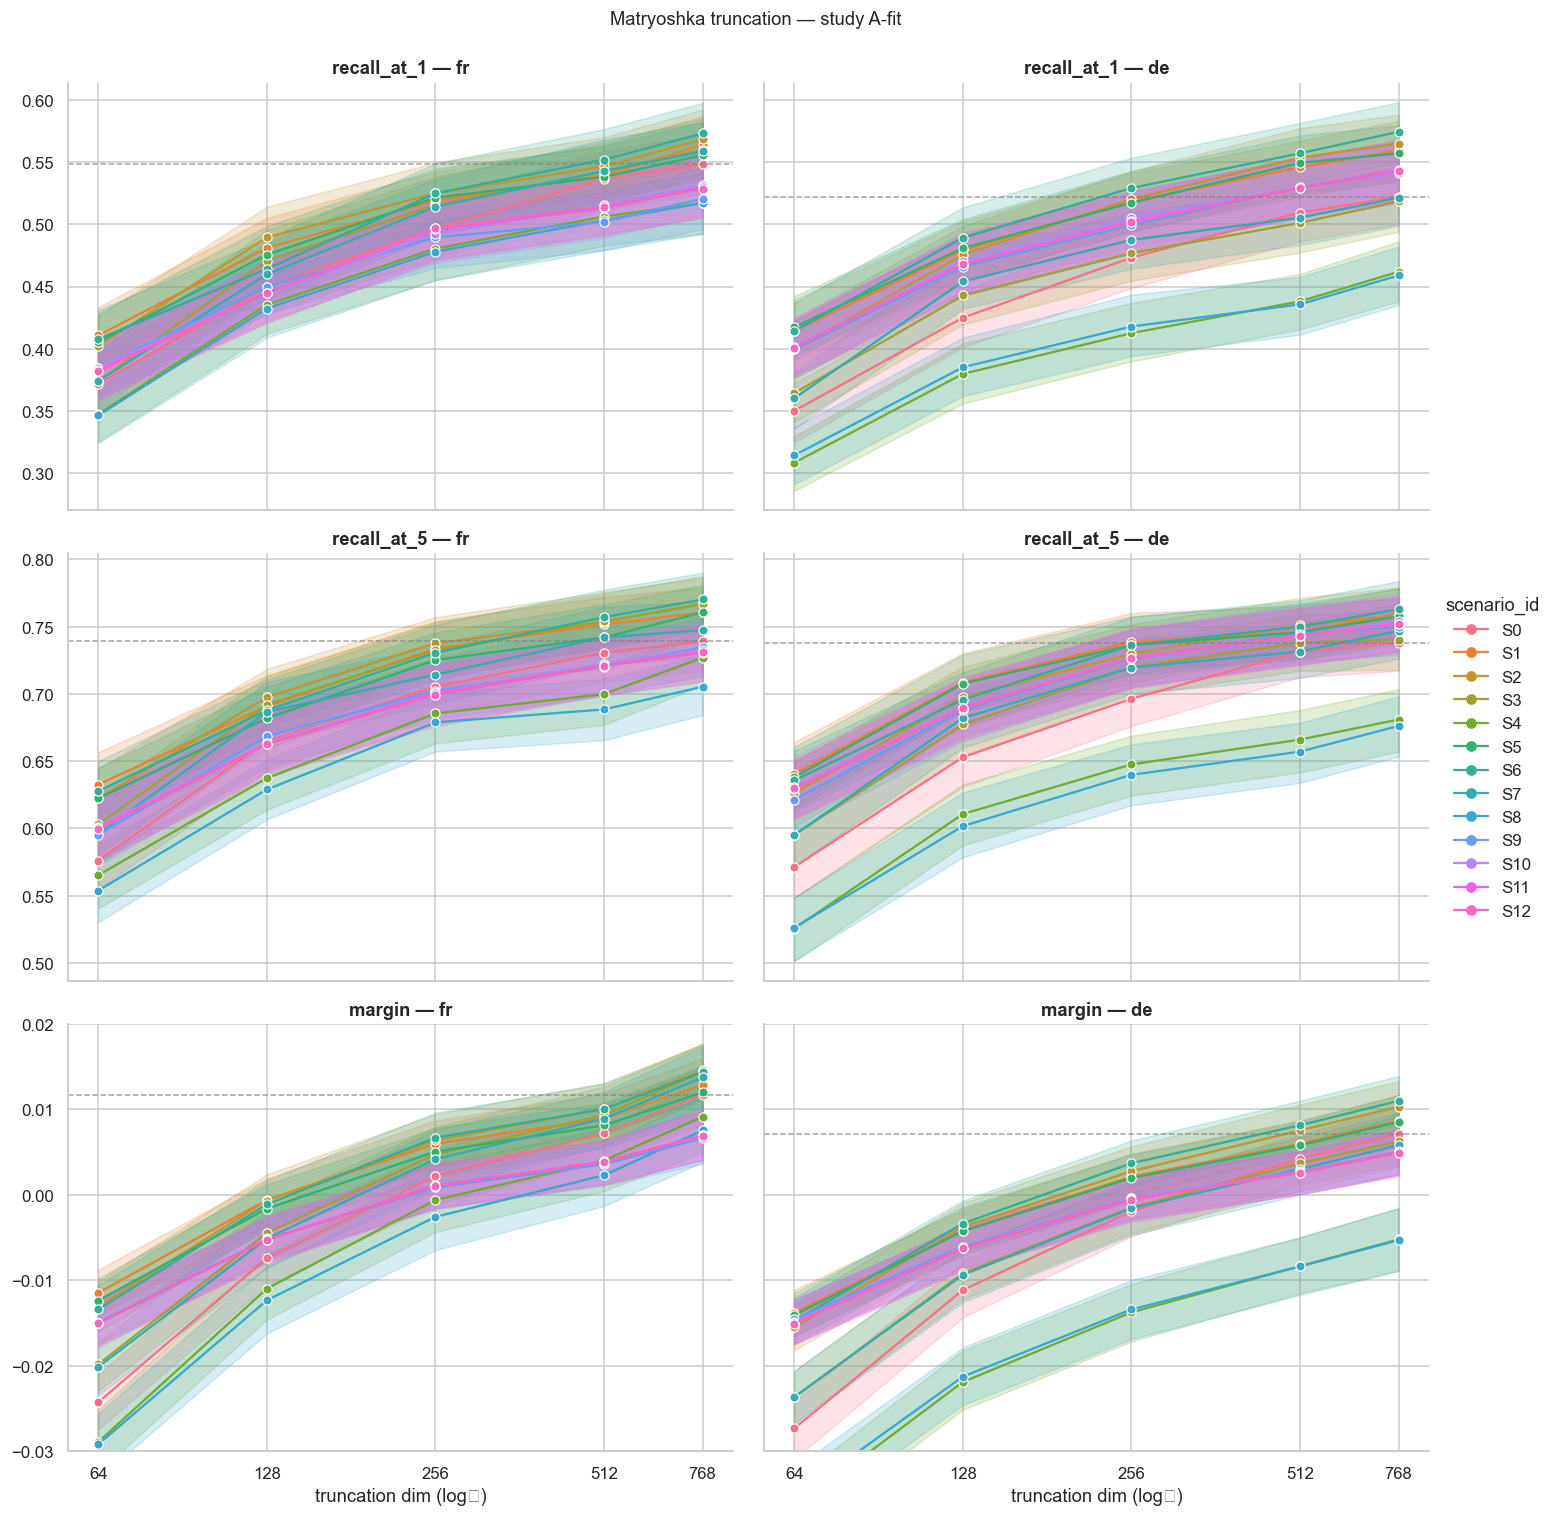

In [13]:
LG_ORDER = list(study_cfg.corpus.languages)                                                                                                           
SCENARIO_ORDER = registry.all_ids()
                                                                                                                                                    
long = sweep.melt(                                                                                                                                    
    id_vars=["truncation_dim", "scenario_id", "lg"],
    value_vars=["recall_at_1", "recall_at_5", "margin"],   # swap to recall_at_5 if that's the raw metric                                                               
    var_name="metric", value_name="value",                                                                                                            
)                                                                                                                                                     
                                                                                                                                                    
g = sns.relplot(                                                                                                                                      
    data=long,                          
    x="truncation_dim", y="value",      
    hue="scenario_id", hue_order=SCENARIO_ORDER,
    row="metric", row_order=["recall_at_1", "recall_at_5", "margin"],                                                                                                   
    col="lg", col_order=LG_ORDER,   
    kind="line", marker="o",                                                                                                                          
    height=4.5, aspect=1.5,          
    errorbar=("ci", 95),                                                                                                                              
    facet_kws={"sharey": "row", "sharex": True},
)                                                                                                                                                     
                                    
for (metric, lg), ax in g.axes_dict.items():                                                                                                          
    ax.set_xscale("log", base=2)     
    ax.set_xticks(DIMS)                 
    ax.set_xticklabels([str(d) for d in DIMS])                                                                                                        
    s0_full = float(                   
        sweep[(sweep.lg == lg)                                                                                                                        
            & (sweep.scenario_id == "S0")                                                                                                           
            & (sweep.truncation_dim == FULL_DIM)][metric].mean()
    )                                                                                                                                                 
    ax.axhline(s0_full, ls="--", color="gray", lw=1, alpha=0.7,                                                                                       
                label=f"S0 @ dim={FULL_DIM} ({s0_full:.3f})")
    if metric == "margin":                                                                                                                            
        ax.set_ylim(-0.03, 0.02)       
                                                                                                                                                    
# bottom row only: keep tick labels visible                                                                                                           
for ax in g.axes[-1]:                   
    ax.tick_params(axis="x", labelbottom=True)                                                                                                        
                                                                                                                                                    
g.set_titles("{row_name} — {col_name}") 
g.set_axis_labels("truncation dim (log₂)", "")                                                                                                        
g.figure.suptitle(                                                                                                                                    
    f"Matryoshka truncation — study {study_cfg.study.name}",
    y=1.02, fontsize=12,                                                                                                                              
)                                                                                                                                                     
plt.show() 

## 6 — TODO follow-ups

Promote into their own cells once the headline curve shape is read:

- Per-scenario Δ vs full-dim with paired bootstrap (reuse `ev.paired_bootstrap_delta`) so we can name the smallest dim that doesn’t lose CI-significantly to dim=768.
- Stratify by `token_bucket` (`ev.DEFAULT_TOKEN_BUCKET_EDGES`) — does dim truncation hurt long docs more, where the mean+L2 aggregate already loses cross-chunk attention?
- Stratify by `position_bucket` (`head` / `mid` / `tail`) — does the prefix preserve head-of-doc retrieval better than tail?
- Cross-port to `notebooks/B-overflow-matryoshka.ipynb` once `study-B-overflow` has its full-dim eval landed.
- Verdict cell: per-language smallest-safe-dim recommendation, citing Δ + CI from the table above.

## Provenance

In [ ]:
print(f"study={study_cfg.study.name}")
print(f"config_sha={study_cfg.config_sha}")
print(f"S3 prefix=s3://{study_cfg.s3.bucket}/{study_cfg.study_s3_root()}/")
print(f"local mirror={study_cfg.study_local_root()}")
print(f"sweep parquet={parquet_path}")
print(f"sweep dims={DIMS}")